# Changes in probabilities after reading articles

## Calculate probabilities

In [ ]:
import pandas as pd
import os
from openai import OpenAI
from dotenv import load_dotenv

XLSX_PATH = "data/news/prob_markets.xlsx"
NUM_RUNS = 3

load_dotenv(override=True)

client = OpenAI(
    api_key=os.getenv("GROQ_API_KEY_1"),
    base_url="https://api.groq.com/openai/v1"
)

MODEL = "llama-3.3-70b-versatile"

RESULT_COLS = [
    "prob_without_article",
    "prob_original_01", "prob_left_01", "prob_right_01",
    "prob_original_02", "prob_left_02", "prob_right_02",
    "prob_original_03", "prob_left_03", "prob_right_03",
    "prob_unrelated",
]

ARTICLE_FIELDS = [
    ("title_01_orignal", "article_01_original", "prob_original_01"),
    ("title_01_left",    "article_01_left",     "prob_left_01"),
    ("title_01_right",   "article_01_right",    "prob_right_01"),
    ("title_02_orignal", "article_02_original", "prob_original_02"),
    ("title_02_left",    "article_02_left",     "prob_left_02"),
    ("title_02_right",   "article_02_right",    "prob_right_02"),
    ("title_03_orignal", "article_03_original", "prob_original_03"),
    ("title_03_left",    "article_03_left",     "prob_left_03"),
    ("title_03_right",   "article_03_right",    "prob_right_03"),
    ("title_unrelated",  "article_unrelated",   "prob_unrelated"),
]


def ask_groq(prompt: str) -> int:
    completion = client.chat.completions.create(
        model=MODEL,
        temperature=0,
        messages=[
            {
                "role": "system",
                "content": "You output ONLY a single integer between 0 and 100."
            },
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    text = completion.choices[0].message.content.strip()

    # Extract integer safely
    for token in text.split():
        token = token.strip(".,;:")
        if token.isdigit():
            return int(token)

    return int("".join(filter(str.isdigit, text)) or "0")


def run_single_pass(df: pd.DataFrame) -> dict:
    results = {col: [] for col in RESULT_COLS}

    for _, row in df.iterrows():
        statement = row["statement"]

        # --- Without article ---
        prompt_base = (
            f"With what probability do you think this event is going to happen:\n"
            f"Event: {statement}\n"
            "Reply with a number from 0 to 100."
        )
        results["prob_without_article"].append(ask_groq(prompt_base))

        # --- With each article ---
        for title_col, article_col, result_col in ARTICLE_FIELDS:
            title = row.get(title_col, "")
            article = row.get(article_col, "")

            prompt_article = (
                f"With what probability do you think this event is going to happen "
                f"after reading this article:\n"
                f"Title: {title}\n"
                f"Text: {article}\n"
                f"Event: {statement}\n"
                "Reply with a number from 0 to 100."
            )

            results[result_col].append(ask_groq(prompt_article))

        print(f"  Done market: {row.get('market', '?')}")

    return results


df = pd.read_excel(XLSX_PATH)
all_runs = {col: [] for col in RESULT_COLS}

for run_idx in range(NUM_RUNS):
    print(f"\n=== Run {run_idx + 1}/{NUM_RUNS} ===")
    run_results = run_single_pass(df)

    for col in RESULT_COLS:
        all_runs[col].append(run_results[col])


for col in RESULT_COLS:
    avg = [
        sum(all_runs[col][r][i] for r in range(NUM_RUNS)) / NUM_RUNS
        for i in range(len(df))
    ]
    df[col] = avg


df.to_excel(XLSX_PATH, index=False)
print(f"\nResults saved to {XLSX_PATH}")

## Analysis of probabilities

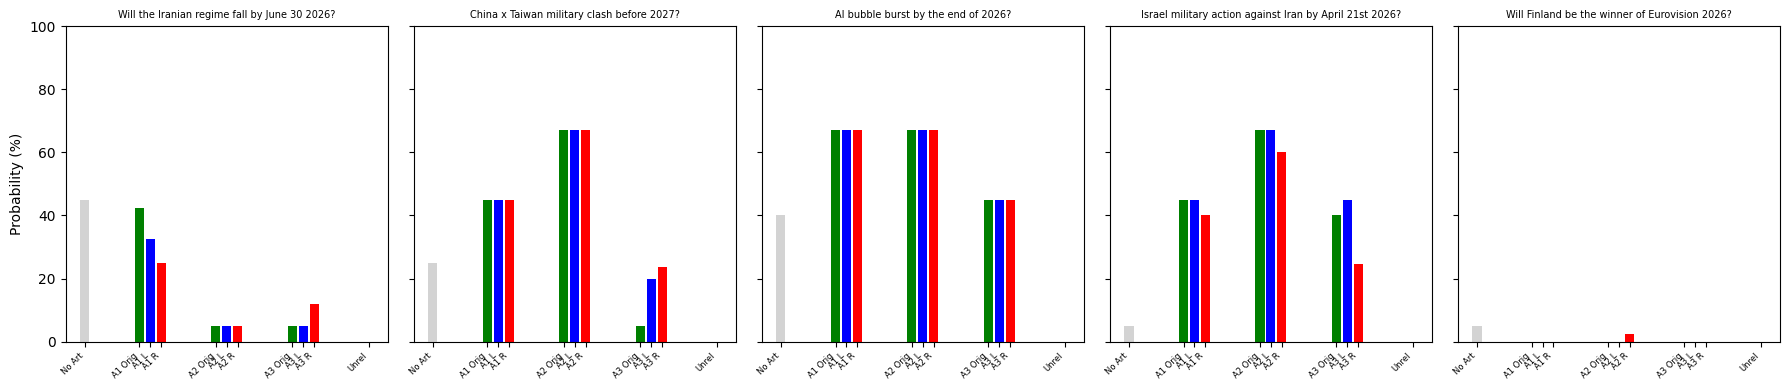

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel("data/news/prob_markets.xlsx")

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

positions = [0, 1.5, 1.8, 2.1, 3.6, 3.9, 4.2, 5.7, 6.0, 6.3, 7.8]
colors    = ["lightgrey", "green","blue","red", "green","blue","red", "green","blue","red", "purple"]
labels    = ["No Art", "A1 Orig","A1 L","A1 R", "A2 Orig","A2 L","A2 R", "A3 Orig","A3 L","A3 R", "Unrel"]
cols      = ["prob_without_article",
             "prob_original_01","prob_left_01","prob_right_01",
             "prob_original_02","prob_left_02","prob_right_02",
             "prob_original_03","prob_left_03","prob_right_03",
             "prob_unrelated"]

for ax, (_, row) in zip(axes, df.iterrows()):
    ax.bar(positions, row[cols].values, width=0.25, color=colors)
    ax.set_title(row["market"], fontsize=7, wrap=True)
    ax.set_ylim(0, 100)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=6, rotation=45, ha='right')

axes[0].set_ylabel("Probability (%)")
plt.tight_layout()
plt.show()

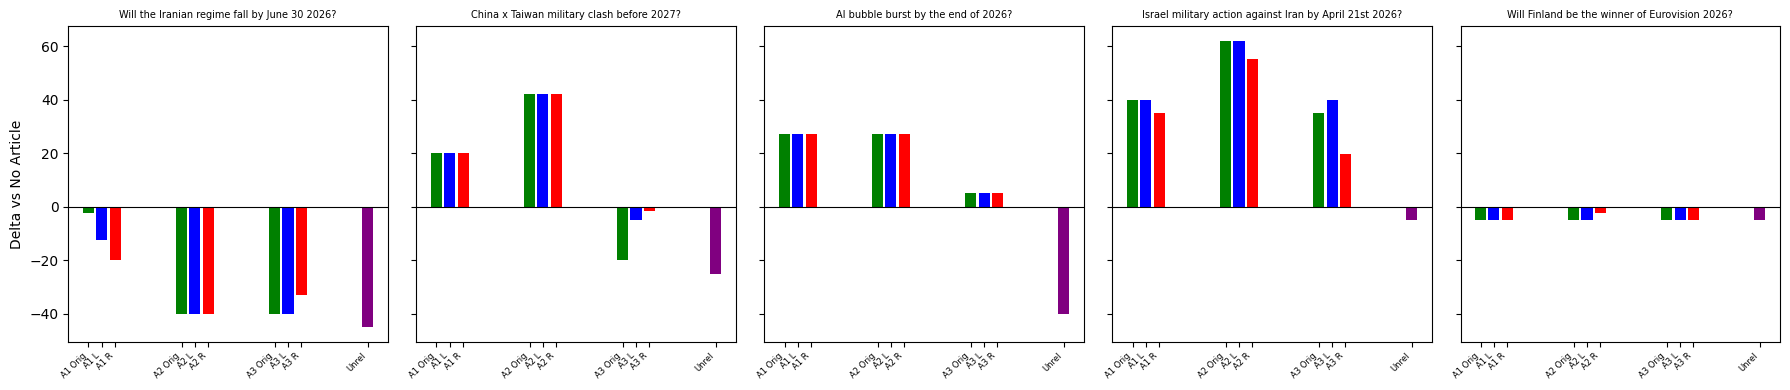

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("data/news/prob_markets.xlsx")

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

positions = [0, 0.3, 0.6, 2.1, 2.4, 2.7, 4.2, 4.5, 4.8, 6.3]
colors    = ["green","blue","red", "green","blue","red", "green","blue","red", "purple"]
labels    = ["A1 Orig","A1 L","A1 R", "A2 Orig","A2 L","A2 R", "A3 Orig","A3 L","A3 R", "Unrel"]
cols      = ["prob_original_01","prob_left_01","prob_right_01",
             "prob_original_02","prob_left_02","prob_right_02",
             "prob_original_03","prob_left_03","prob_right_03",
             "prob_unrelated"]

for ax, (_, row) in zip(axes, df.iterrows()):
    deltas = row[cols].values - row["prob_without_article"]
    ax.bar(positions, deltas, width=0.25, color=colors)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(row["market"], fontsize=7, wrap=True)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=6, rotation=45, ha='right')

axes[0].set_ylabel("Delta vs No Article")
plt.tight_layout()
plt.show()

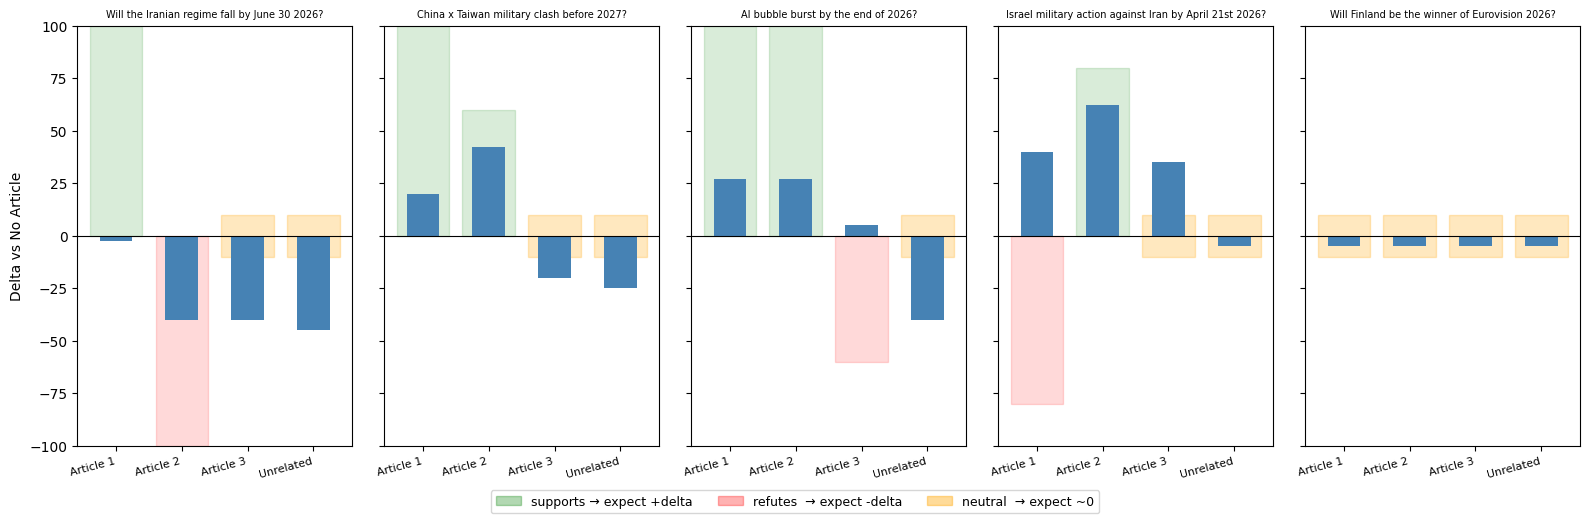

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_excel("data/news/prob_markets.xlsx")

art_cols    = ["prob_original_01", "prob_original_02", "prob_original_03", "prob_unrelated"]
stance_cols = ["stance_01", "stance_02", "stance_03", None]
help_cols   = ["helpfulness_01", "helpfulness_02", "helpfulness_03", None]
labels      = ["Article 1", "Article 2", "Article 3", "Unrelated"]

fig, axes = plt.subplots(1, 5, figsize=(16, 5), sharey=True)

for ax, (_, row) in zip(axes, df.iterrows()):
    ymin = min(row[art_cols].min() - row["prob_without_article"], 0) - 5
    ymax = max(row[art_cols].max() - row["prob_without_article"], 0) + 5

    for i, (col, scol, hcol, label) in enumerate(zip(art_cols, stance_cols, help_cols, labels)):
        delta  = row[col] - row["prob_without_article"]
        stance = str(row[scol]).strip().lower() if scol and pd.notna(row[scol]) else "neutral"
        h      = row[hcol] / 5 if hcol and pd.notna(row[hcol]) else 1.0

        # shade expected region based on stance
        if stance == "supports":
            ax.axvspan(i - 0.4, i + 0.4, ymin=0.5, ymax=0.5 + 0.5 * h, color="green", alpha=0.15)
        elif stance == "refutes":
            ax.axvspan(i - 0.4, i + 0.4, ymin=0.5 - 0.5 * h, ymax=0.5, color="red", alpha=0.15)
        else:
            ax.axvspan(i - 0.4, i + 0.4, ymin=0.45, ymax=0.55, color="orange", alpha=0.25)

        ax.bar(i, delta, width=0.5, color="steelblue", zorder=3)

    ax.axhline(0, color='black', linewidth=0.8, zorder=4)
    ax.set_title(row["market"], fontsize=7, wrap=True)
    ax.set_xticks(range(4))
    ax.set_xticklabels(labels, fontsize=8, rotation=15, ha='right')

axes[0].set_ylabel("Delta vs No Article")
for ax in axes:
    ax.set_ylim(-100, 100)

legend = [
    mpatches.Patch(color="green",  alpha=0.3, label="supports → expect +delta"),
    mpatches.Patch(color="red",    alpha=0.3, label="refutes  → expect -delta"),
    mpatches.Patch(color="orange", alpha=0.4, label="neutral  → expect ~0"),
]
fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

df = pd.read_excel("data/news/prob_markets.xlsx")

deltas = {"supports": [], "refutes": [], "neutral": []}

for _, row in df.iterrows():
    for n in ["01", "02", "03"]:
        stance = str(row[f"stance_{n}"]).strip().lower()
        delta = row[f"prob_original_{n}"] - row["prob_without_article"]
        if stance in deltas:
            deltas[stance].append(delta)

for stance, vals in deltas.items():
    print(f"{stance}: avg delta = {sum(vals)/len(vals):.2f} (n={len(vals)})")

unrelated_deltas = df["prob_unrelated"] - df["prob_without_article"]
print(f"unrelated: avg delta = {unrelated_deltas.mean():.2f} (n={len(unrelated_deltas)})")

supports: avg delta = 29.25 (n=6)
refutes: avg delta = 1.67 (n=3)
neutral: avg delta = -6.67 (n=6)
unrelated: avg delta = -24.00 (n=5)


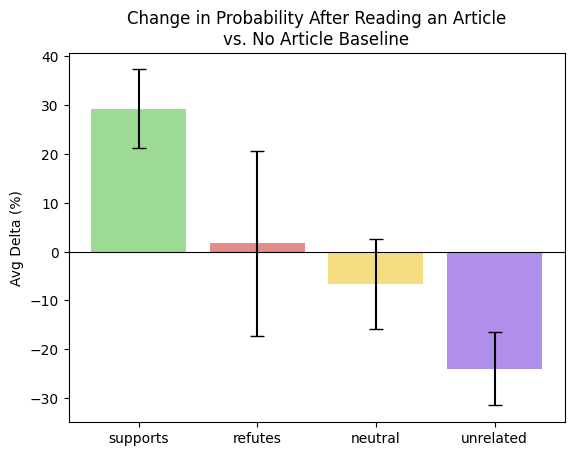

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel("data/news/prob_markets.xlsx")

deltas = {"supports": [], "refutes": [], "neutral": []}
for _, row in df.iterrows():
    for n in ["01", "02", "03"]:
        stance = str(row[f"stance_{n}"]).strip().lower()
        delta = row[f"prob_original_{n}"] - row["prob_without_article"]
        if stance in deltas:
            deltas[stance].append(delta)

unrel = list(df["prob_unrelated"] - df["prob_without_article"])
all_groups = {**deltas, "unrelated": unrel}

means = [np.mean(v) for v in all_groups.values()]
sems  = [np.std(v) / np.sqrt(len(v)) for v in all_groups.values()]

plt.bar(all_groups.keys(), means, yerr=sems, capsize=5,
        color=["#9dda95","#e58b8a","#f6dd82","#af8fea"])
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel("Avg Delta (%)")
plt.title("Change in Probability After Reading an Article\nvs. No Article Baseline")
plt.show()

## Ask LLM if article supports, refutes, is neutral or is unrelated.

In [ ]:
import pandas as pd
import json
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv(override=True)

client = OpenAI(
    api_key=os.getenv("GROQ_API_KEY_1"),
    base_url="https://api.groq.com/openai/v1"
)
MODEL = "llama-3.3-70b-versatile"

df = pd.read_excel("data/news/prob_markets.xlsx")

PROMPT = """After reading this article, do you think it could slightly support or refute the following statement? Or is it neutral or unrelated to it?
Title: {title}
Text: {article}
Statement: {statement}
Reply only with a JSON object like this: {{"stance": "supports/refutes/neutral/unrelated", "reason": "1-2 sentence explanation"}}. No extra text."""

article_fields = [
    ("title_01_orignal", "article_01_original", "llm_stance_01", "llm_reason_01"),
    ("title_02_orignal", "article_02_original", "llm_stance_02", "llm_reason_02"),
    ("title_03_orignal", "article_03_original", "llm_stance_03", "llm_reason_03"),
    ("title_unrelated",  "article_unrelated",   "llm_stance_unrelated", "llm_reason_unrelated"),
]

def ask_groq(prompt):
    resp = client.chat.completions.create(model=MODEL, messages=[{"role": "user", "content": prompt}])
    text = resp.choices[0].message.content.strip()
    parsed = json.loads(text)
    return parsed["stance"].strip().lower(), parsed["reason"].strip()

for *_, stance_col, reason_col in article_fields:
    df[stance_col] = ""
    df[reason_col] = ""

for idx, row in df.iterrows():
    for title_col, article_col, stance_col, reason_col in article_fields:
        prompt = PROMPT.format(title=row[title_col], article=row[article_col], statement=row["statement"])
        stance, reason = ask_groq(prompt)
        df.at[idx, stance_col] = stance
        df.at[idx, reason_col] = reason
        print(f"Market: {row['market']} | {stance_col}: {stance}")

df.to_excel("data/news/prob_markets_with_llm_stances.xlsx", index=False)
print("Done!")

Market: Will the Iranian regime fall by June 30 2026? | llm_stance_01: neutral
Market: Will the Iranian regime fall by June 30 2026? | llm_stance_02: refutes
Market: Will the Iranian regime fall by June 30 2026? | llm_stance_03: unrelated
Market: Will the Iranian regime fall by June 30 2026? | llm_stance_unrelated: unrelated
Market: China x Taiwan military clash before 2027? | llm_stance_01: refutes
Market: China x Taiwan military clash before 2027? | llm_stance_02: neutral
Market: China x Taiwan military clash before 2027? | llm_stance_03: unrelated
Market: China x Taiwan military clash before 2027? | llm_stance_unrelated: unrelated
Market: AI bubble burst by the end of 2026? | llm_stance_01: neutral
Market: AI bubble burst by the end of 2026? | llm_stance_02: neutral
Market: AI bubble burst by the end of 2026? | llm_stance_03: refutes
Market: AI bubble burst by the end of 2026? | llm_stance_unrelated: unrelated
Market: Israel military action against Iran by April 21st 2026? | llm_sta

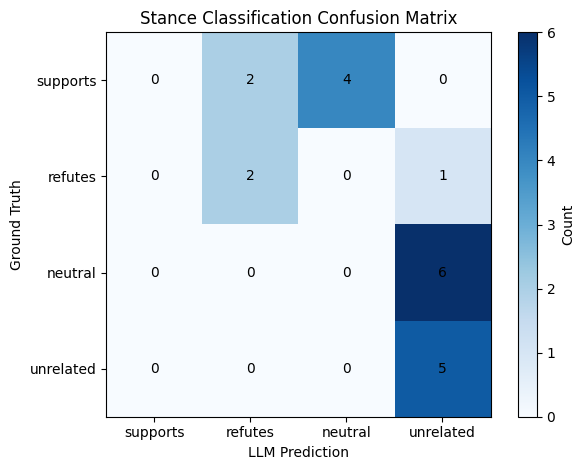

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("data/news/prob_markets_with_llm_stances.xlsx")

cats = ["supports", "refutes", "neutral", "unrelated"]
matrix = pd.DataFrame(0, index=cats, columns=cats)

for _, row in df.iterrows():
    for true_col, pred_col in [("stance_01","llm_stance_01"),("stance_02","llm_stance_02"),("stance_03","llm_stance_03")]:
        true = str(row[true_col]).strip().lower()
        pred = str(row[pred_col]).strip().lower()
        if true in cats and pred in cats:
            matrix.loc[true, pred] += 1
    pred = str(row["llm_stance_unrelated"]).strip().lower()
    if pred in cats:
        matrix.loc["unrelated", pred] += 1

fig, ax = plt.subplots()
im = ax.imshow(matrix, cmap="Blues")
plt.colorbar(im, ax=ax, label="Count")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(cats); ax.set_yticklabels(cats)
ax.set_xlabel("LLM Prediction"); ax.set_ylabel("Ground Truth")
ax.set_title("Stance Classification Confusion Matrix")

for i in range(4):
    for j in range(4):
        ax.text(j, i, matrix.iloc[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

In [27]:
import pandas as pd

df = pd.read_excel("data/news/prob_markets_with_llm_stances.xlsx")

rows = []
for _, row in df.iterrows():
    for true_col, pred_col in [("stance_01","llm_stance_01"),("stance_02","llm_stance_02"),("stance_03","llm_stance_03")]:
        rows.append({"ground_truth": str(row[true_col]).strip().lower(), "llm_prediction": str(row[pred_col]).strip().lower()})
    rows.append({"ground_truth": "unrelated", "llm_prediction": str(row["llm_stance_unrelated"]).strip().lower()})

results = pd.DataFrame(rows)
results["correct"] = results["ground_truth"] == results["llm_prediction"]

summary = results.groupby("ground_truth")["correct"].agg(correct="sum", total="count")
summary["pct"] = (summary["correct"] / summary["total"] * 100).round(1)

print(summary.to_string())
print(f"\nOverall: {results['correct'].sum()}/{len(results)} ({results['correct'].mean()*100:.1f}%)")

rows = []
for _, row in df.iterrows():
    for true_col, pred_col, n in [("stance_01","llm_stance_01","1"),("stance_02","llm_stance_02","2"),("stance_03","llm_stance_03","3")]:
        rows.append({"market": row["market"], "article": n, "ground_truth": row[true_col], "llm_prediction": row[pred_col]})
    rows.append({"market": row["market"], "article": "unrelated", "ground_truth": "unrelated", "llm_prediction": row["llm_stance_unrelated"]})

print(pd.DataFrame(rows).to_string(index=False))

              correct  total    pct
ground_truth                       
neutral             0      6    0.0
refutes             2      3   66.7
supports            0      6    0.0
unrelated           5      5  100.0

Overall: 7/20 (35.0%)
                                                 market   article ground_truth llm_prediction
          Will the Iranian regime fall by June 30 2026?         1     supports        neutral
          Will the Iranian regime fall by June 30 2026?         2      refutes        refutes
          Will the Iranian regime fall by June 30 2026?         3      neutral      unrelated
          Will the Iranian regime fall by June 30 2026? unrelated    unrelated      unrelated
             China x Taiwan military clash before 2027?         1     supports        refutes
             China x Taiwan military clash before 2027?         2     supports        neutral
             China x Taiwan military clash before 2027?         3      neutral      unrelated
         